In [1]:
import sys
sys.path.append('../src')

import numpy as np
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt

import torch
import pickle
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

from qiskit import QuantumCircuit

# simulation and circuit generation
from third_meeting.noisy_8_qubit import get_circuits_and_outputs
from utils import simulate_with_noise_3D

# plot and ML model
from sixth_meeting.visualizer import TransitionPointsVisualizer
from fifth_meeting.create_dataset import get_supermarq_features
from fifth_meeting.create_dataset import HammingDecayPredictor

print("All imports successful!")

All imports successful!


# Part 0: Generate random variational circuits and simulate them

## Generate circuits 5 times to collect good amount of training data and save them

In [2]:
# runs = 8

# # Collect circuits for multiple runs
# data = []
# for i in range(runs):
#     print(f"Run {i+1}/{runs}")
#     circuits_and_outputs = get_circuits_and_outputs()
#     data.append(circuits_and_outputs)

# # Save the collected circuits and outputs to a file
# with open('../data/sixth_meeting/collected_circuits_and_outputs.pkl', 'wb') as f:
#     pickle.dump(data, f)


## Only keep circuits 1 to 18 (variational) 

In [3]:
# # Load the collected circuits and outputs from the file
# with open('../data/sixth_meeting/collected_circuits_and_outputs.pkl', 'rb') as f:
#     data = pickle.load(f)

# filtered_data = []
# for run_data in data:
#     names = run_data['names']
#     true_circuits = run_data['true_circuits']
#     true_dists = run_data['true_dists']
#     mirrored_circuits = run_data['mirrored_circuits']
#     true_outputs = run_data['true_outputs']

#     # Only keep circuits 1:18 from each run
#     filtered_run_data = {
#         'names': names[1:19],
#         'true_circuits': true_circuits[1:19],
#         'true_dists': true_dists[1:19],
#         'mirrored_circuits': mirrored_circuits[1:19],
#         'true_outputs': true_outputs[1:19]
#     }

#     filtered_data.append(filtered_run_data)

# # Save the circuit dataset to a file
# with open('../data/sixth_meeting/filtered_circuits_and_outputs.pkl', 'wb') as f:
#     pickle.dump(filtered_data, f)

## Flatten data

In [4]:
# # load filtered data from file
# with open('../data/sixth_meeting/filtered_circuits_and_outputs.pkl', 'rb') as f:
#     filtered_data = pickle.load(f)

# # Flatten the filtered data for easier processing, edit name to include run index
# flattened_data = []
# for run_index, run_data in enumerate(filtered_data):
#     for i in range(len(run_data['names'])):
#         flattened_data.append((run_data['names'][i] + f"_r{run_index}", run_data['true_circuits'][i], run_data['true_dists'][i], run_data['mirrored_circuits'][i], run_data['true_outputs'][i], run_index))

# # save the flattened data to a file
# with open('../data/sixth_meeting/flattened_circuits_and_outputs.pkl', 'wb') as f:
#     pickle.dump(flattened_data, f)

## Simulate the circuits with 0.02 noise

In [5]:
# # load flattened data from file
# with open('../data/sixth_meeting/flattened_circuits_and_outputs.pkl', 'rb') as f:
#     circuit_dataset = pickle.load(f)


# # circuit dataset is a list of tuples: (name, true_circuit, true_dist, mirrored_circuit, true_output, run_index)
# # extract using list comprehension and convert to numpy array for easier indexing
# circuit_dataset = np.array(circuit_dataset, dtype=object)
# names = circuit_dataset[:, 0]
# true_circuits = circuit_dataset[:, 1]
# true_dists = circuit_dataset[:, 2]
# mirrored_circuits = circuit_dataset[:, 3]
# true_outputs = circuit_dataset[:, 4]

# # simulate with 0.2% noise and varying shot counts, save results to file

# noise_levels = [0.002]
# shot_counts = np.arange(50, 1250, 20)

# for circuit_index in range(len(names)):
#     mirrored_circuit = mirrored_circuits[circuit_index]
#     true_output = true_outputs[circuit_index]

#     true_circuit = true_circuits[circuit_index]
#     true_dist = true_dists[circuit_index]

#     hellinger_data = simulate_with_noise_3D(
#              true_circuit, true_dist, noise_levels=noise_levels, shot_counts=shot_counts, distance_type='hellinger'
#     )

#     hamming_data = []
#     for i in range(10):
#         print(f"Simulation run {i+1}/10 for circuit index {circuit_index}")
#         H = simulate_with_noise_3D(
#             mirrored_circuit, true_output, noise_levels=noise_levels, shot_counts=shot_counts, distance_type='hamming'
#         )
#         hamming_data.append(H)

#     np.savez_compressed(
#         f'../data/sixth_meeting/sim/circuit_{circuit_index}_data.npz',
#         name=circuit_dataset[circuit_index, 0],
#         shots_array=shot_counts,
#         noise_intensities=noise_levels,
#         hamming_data=hamming_data,
#         hellinger_data=hellinger_data
#     )

## Put circuit data and simulation data into a single dataset

In [6]:
# with open('../data/sixth_meeting/flattened_circuits_and_outputs.pkl', 'rb') as f:
#     circuit_dataset = pickle.load(f)

# circuit_dataset = np.array(circuit_dataset, dtype=object)
# names = circuit_dataset[:, 0]

# true_circuits = circuit_dataset[:, 1]
# true_dists = circuit_dataset[:, 2]
# mirrored_circuits = circuit_dataset[:, 3]
# true_outputs = circuit_dataset[:, 4]

# # numpy array of tuples: (name, true_circuit, true_dist, mirrored_circuit, true_output)
# circuits_info = np.array(list(zip(true_circuits, true_dists, mirrored_circuits, true_outputs)), dtype=object)


# # Load all circuit simulation data and put it into one file

# shots_dataset = []
# noise_dataset = []
# hamming_dataset = []
# hellinger_dataset = []

# for circuit_index in range(len(names)):
#     loaded = np.load(f'../data/sixth_meeting/sim/circuit_{circuit_index}_data.npz', allow_pickle=True)
#     shots_dataset.append(loaded['shots_array'])
#     noise_dataset.append(loaded['noise_intensities'])
#     hamming_dataset.append(loaded['hamming_data'])
#     hellinger_dataset.append(loaded['hellinger_data'])

# shots_dataset = np.array(shots_dataset, dtype=int)
# noise_dataset = np.array(noise_dataset, dtype=int)
# hamming_dataset = np.array(hamming_dataset, dtype=float)
# hellinger_dataset = np.array(hellinger_dataset, dtype=float)

# # print(names.shape, circuits_info.shape, shots_dataset.shape, noise_dataset.shape, hamming_dataset.shape, hellinger_dataset.shape)

# # Save all data into one file
# np.savez_compressed(
#     f'../data/sixth_meeting/circuits_simulation_dataset.npz',
#     name=names,
#     circuit_info=circuits_info,
#     shots_range=shots_dataset,
#     noise_range=noise_dataset,
#     hamming_outputs=hamming_dataset,
#     hellinger_outputs=hellinger_dataset
# )

# Part 1: Extract important parameters from the data

## Pre-process for visualization

In [7]:
# loaded = np.load(f'../data/sixth_meeting/circuits_simulation_dataset.npz', allow_pickle=True)
# names_dataset = loaded['name']
# circuits_info_dataset = loaded['circuit_info']
# shots_dataset = loaded['shots_range']
# noise_dataset = loaded['noise_range']
# hamming_dataset = loaded['hamming_outputs']
# hellinger_dataset = loaded['hellinger_outputs']


# smoothed_hellinger = np.array([
#             [savgol_filter(savgol_filter(hellinger_dataset[i][j], 11, 2), 11, 2)
#              for j in range(len(noise_dataset[i]))]
#             for i in range(len(names_dataset))
#         ])

# smoothed_hamming = np.array([
#             [[savgol_filter(savgol_filter(hamming_dataset[i][j][k], 11, 2), 11, 2)
#               for k in range(len(noise_dataset[i]))]
#              for j in range(10)]
#             for i in range(len(names_dataset))
#         ])

# smoothed_hamming_std = [np.std(hamming_data, axis=0) for hamming_data in smoothed_hamming]


## Pre-compute hyperbolic function fitted on the Haming and Hellinger data

In [8]:
# Fit hyperbolic decay curves to the smoothed data ((A / B * x) + C, A - initial value, B - decay rate, C - asymptotic value (bias))
def hyperbolic_decay(x, A, B, C):
    return (A / (B * x)) + C

def exponential_decay(x, A, B, C):
    return A * np.exp(-B * x) + C

def fit_curve_to_data(x_data, y_data, poly_type=exponential_decay):

    # Initial A, B, C guesses
    C_guess = np.mean(y_data[-5:])  # Estimate offset from last few points
    A_guess = np.max(y_data) - C_guess  # Amplitude from peak minus offset

    non_zero_mask = y_data - C_guess > 0.01
    if np.sum(non_zero_mask) > 2:
        log_y = np.log(y_data[non_zero_mask] - C_guess)
        x_for_fit = x_data[non_zero_mask]
        B_guess = -np.polyfit(x_for_fit, log_y, 1)[0]
    else:
        B_guess = 0.1  # Default guess

    initial_guess = [A_guess, B_guess, C_guess]

    # Apply Nonlinear Least Squares fitting for A, B, C
    try:
        # Basic fit
        params_opt, params_cov = curve_fit(
            poly_type, 
            x_data, 
            y_data,
            p0=initial_guess,
            maxfev=10000  # Increase max function evaluations
        )
        
        A_fit, B_fit, C_fit = params_opt
        perr = np.sqrt(np.diag(params_cov))  # Parameter uncertainties
        
    except RuntimeError as e:
        print(f"Optimization failed: {e}")
        print("Trying with bounds...")
        
        # Try with bounds to help convergence
        params_opt, params_cov = curve_fit(
            poly_type,
            x_data,
            y_data,
            p0=initial_guess,
            bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),  # A,B ≥ 0
            maxfev=10000
        )
        
        A_fit, B_fit, C_fit = params_opt

    # return predicted values and parameters
    return A_fit, B_fit, C_fit

## ABC parameters correction for the flat hammings to decrease the ratios std as much as possible 

In [9]:
# # Precompute the exponential decay parameters for all circuits and noise levels
# poly_hellinger_ABC = np.array([
#                 [fit_curve_to_data(shots_dataset[i], smoothed_hellinger[i][j])
#                 for j in range(len(noise_dataset[i]))]
#                 for i in range(len(names_dataset))
#             ])

# poly_hamming_std_ABC = np.array([
#                 [fit_curve_to_data(shots_dataset[i], smoothed_hamming_std[i][j])
#                 for j in range(len(noise_dataset[i]))]
#                 for i in range(len(names_dataset))
#             ])

# # Values for correction found with grid search
# for i in range(len(poly_hamming_std_ABC)):
#     for j in range(len(poly_hamming_std_ABC[i])):
#         corrected_A = poly_hamming_std_ABC[i][j][0]
#         corrected_B = poly_hamming_std_ABC[i][j][1]
#         corrected_C = poly_hamming_std_ABC[i][j][2]

#         # Correction for A and B to make the curve steeper if it's too flat, based on the best parameters found from grid search
#         if corrected_A < 0.1419:
#             corrected_A = corrected_A * (0.1419 / corrected_A) * 2.0303
#         if corrected_B < 0.01:
#             corrected_B = corrected_B * (0.01 / corrected_B) * 1.8221

#         poly_hamming_std_ABC[i][j] = (corrected_A, corrected_B, corrected_C)

## Relation between A, B, C parameters of the actual hellinger/ hamming_std

In [10]:
# parameters = ['A', 'B', 'C']
# fig, axs = plt.subplots(1, 3, figsize=(18, 5))
# mean_ratios = []

# for i, param in enumerate(parameters):
#     ratios = []
#     for circuit_idx in range(len(names_dataset)):

#         hellinger_param = poly_hellinger_ABC[circuit_idx][0][i]
#         hamming_param = poly_hamming_std_ABC[circuit_idx][0][i]
#         if hamming_param != 0:
#             ratios.append(hellinger_param / hamming_param)

#     axs[i].hist(ratios, bins=80, color='b', alpha=0.7, edgecolor='black')
#     axs[i].set_title(f'Distribution of {param}_Hellinger / {param}_Hamming Ratios')
#     axs[i].set_xlabel('Ratio Value')
#     axs[i].set_ylabel('Frequency')
#     axs[i].grid(True, alpha=0.3)

#     # --- Fit a bell curve to the histogram and display mean and std on the plot
#     mean = np.mean(ratios)
#     std = np.std(ratios)
#     x_fit = np.linspace(min(ratios), max(ratios), 100)
#     y_fit = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_fit - mean) / std) ** 2)
#     axs[i].plot(x_fit, y_fit * len(ratios) * (max(ratios) - min(ratios)) / 80, color='r', label=f'Fit: μ={mean:.4f}, σ={std:.4f}')
#     axs[i].legend()
#     mean_ratios.append(mean)
# plt.tight_layout()
# plt.show()

## Grid search for ratios that give the best possible result within std from the mean

In [11]:
# # Use grid search to find the optimal means for A, B, C that minimize the average distance between actual and predicted Hellinger saturation points across all circuits and noise levels
# ratios_A = np.linspace(1.6724 - 0.5904, 1.6724 + 0.5904, 100)
# ratios_B = np.linspace(0.1958 - 0.0509, 0.1958 + 0.0509, 100)
# ratios_C = [10.1770] #np.linspace(10.1770 - 3.5104, 10.1770 + 3.5104, 10)
# slope_range = np.arange(0.00012, 0.00030, 0.00003)

# smallest_average_distance = float('inf')
# best_m_A, best_m_B, best_m_C = None, None, None
# best_slope_threshold = None

# for m_A in ratios_A:
#     print(f"Testing m_A: {m_A:.4f}")
#     for m_B in ratios_B:
#         for m_C in ratios_C:
#             for slope_threshold in slope_range:
#                 poly_predicted_hellinger_ABC = np.array([
#                     [(m_A * poly_hamming_std_ABC[i][j][0], m_B * poly_hamming_std_ABC[i][j][1], m_C * poly_hamming_std_ABC[i][j][2])]
#                     for j in range(len(noise_dataset[i]))
#                     for i in range(len(names_dataset))
#                 ])

#                 # Calculate Hellinger saturation points using the predicted parameters and compare to actual Hellinger saturation points
#                 hellinger_points = []
#                 predicted_hellinger_points = []

#                 # Calculate the saturation points for every circuit, every noise and slope level in the specified range, and store them in a list to be plotted later
#                 for circuit_idx in range(len(names_dataset)):
#                     hellinger_points_circuit = []
#                     predicted_hellinger_points_circuit = []
#                     for noise_idx in range(len(noise_dataset[circuit_idx])):
#                         hellinger_points_noise = []
#                         predicted_hellinger_points_noise = []
#                         for slope_threshold in [slope_threshold]: # only use the current slope threshold for this iteration
#                             A, B, _ = poly_hellinger_ABC[circuit_idx][noise_idx]
#                             point_idx = np.where(np.abs(-A * B * np.exp(-B * shots_dataset[circuit_idx])) < slope_threshold)[0]
#                             hellinger_points_noise.append(point_idx[0])

#                             A_pred, B_pred, _ = poly_predicted_hellinger_ABC[circuit_idx * len(noise_dataset[circuit_idx]) + noise_idx][0]
#                             point_idx_pred = np.where(np.abs(-A_pred * B_pred * np.exp(-B_pred * shots_dataset[circuit_idx])) < slope_threshold)[0]
#                             # check if point_idx_pred is empty, if so, set it to the last index of shots_dataset[circuit_idx]
#                             if len(point_idx_pred) == 0:
#                                 point_idx_pred = [89]
#                             predicted_hellinger_points_noise.append(point_idx_pred[0])
#                         hellinger_points_circuit.append(hellinger_points_noise)
#                         predicted_hellinger_points_circuit.append(predicted_hellinger_points_noise)
#                     hellinger_points.append(hellinger_points_circuit)
#                     predicted_hellinger_points.append(predicted_hellinger_points_circuit)

#                 # Calculate the average distance across all circuits and noise levels between actual and predicted Hellinger saturation points
#                 # We want to punish hard big differences more than many small differences, so we will use the square of the distance instead of the absolute value
#                 total_distance = 0
#                 for circuit_idx in range(len(names_dataset)):
#                     for noise_idx in range(len(noise_dataset[circuit_idx])):
#                         actual_point_idx = hellinger_points[circuit_idx][noise_idx][0]
#                         predicted_point_idx = predicted_hellinger_points[circuit_idx][noise_idx][0]
#                         total_distance += (actual_point_idx - predicted_point_idx) ** 2 # square of the difference between the indices
#                 average_distance = total_distance / (90 ** 2) # normalize by the square of the number of points to get a value between 0 and 1

#                 if average_distance < smallest_average_distance:
#                     smallest_average_distance = average_distance
#                     best_m_A, best_m_B, best_m_C = m_A, m_B, m_C
#                     best_slope_threshold = slope_threshold
#             #print(f"current m_A: {m_A:.4f}, m_B: {m_B:.4f}, m_C: {m_C:.4f}, current average distance: {average_distance:.4f}")
#     print(f"Best m_A: {best_m_A:.4f}, Best m_B: {best_m_B:.4f}, Best m_C: {best_m_C:.4f}, Best Slope Threshold: {best_slope_threshold:.4f}, Best Average Distance: {smallest_average_distance:.4f}") 
# # Best m_A: 1.8453, Best m_B: 0.2467, Best m_C: 10.1770, Best Slope Threshold: 0.0005, Best Average Distance: 2.5778
# # Best m_A: 2.1674, Best m_B: 0.2385, Best m_C: 10.1770, Best Slope Threshold: 0.0003, Best Average Distance: 2.8667 # improved slope range
# # Best m_A: 1.9527, Best m_B: 0.2313, Best m_C: 10.1770, Best Slope Threshold: 0.0003, Best Average Distance: 13.2556 # SQUARED DISTANCES

## Use ratios to predict Hellinger ONLY from Hamming std

In [12]:
# m_A, m_B, m_C = (1.9527, 0.2313, 10.1770) # best parameters found from grid search
# poly_predicted_hellinger_ABC = np.array([
#                 [(m_A * poly_hamming_std_ABC[i][j][0], m_B * poly_hamming_std_ABC[i][j][1], m_C * poly_hamming_std_ABC[i][j][2])]
#                 for j in range(len(noise_dataset[i]))
#                 for i in range(len(names_dataset))
#             ])

## Pre-compute the saturation points

In [13]:
# slope_range = np.arange(0.00012, 0.0005, 0.00003)
# hellinger_points = []
# predicted_hellinger_points = []

# # Calculate the saturation points for every circuit, every noise and slope level in the specified range, and store them in a list to be plotted later
# for circuit_idx in range(len(names_dataset)):
#     hellinger_points_circuit = []
#     predicted_hellinger_points_circuit = []
#     for noise_idx in range(len(noise_dataset[circuit_idx])):
#         hellinger_points_noise = []
#         predicted_hellinger_points_noise = []
#         for slope_threshold in slope_range:
#             A, B, _ = poly_hellinger_ABC[circuit_idx][noise_idx]
#             point_idx = np.where(np.abs(-A * B * np.exp(-B * shots_dataset[circuit_idx])) < slope_threshold)[0]
#             hellinger_points_noise.append(point_idx[0])

#             A_pred, B_pred, _ = poly_predicted_hellinger_ABC[circuit_idx * len(noise_dataset[circuit_idx]) + noise_idx][0]
#             point_idx_pred = np.where(np.abs(-A_pred * B_pred * np.exp(-B_pred * shots_dataset[circuit_idx])) < slope_threshold)[0]
#             predicted_hellinger_points_noise.append(point_idx_pred[0])
#         hellinger_points_circuit.append(hellinger_points_noise)
#         predicted_hellinger_points_circuit.append(predicted_hellinger_points_noise)
#     hellinger_points.append(hellinger_points_circuit)
#     predicted_hellinger_points.append(predicted_hellinger_points_circuit)

# # # print average difference between actual and predicted Hellinger saturation points across all circuits and noise levels for each slope threshold
# # # print the slope with the smallest average difference
# # min_avg_diff = float('inf')
# # best_slope = None
# # for slope_index in range(len(slope_range)):
# #     total_diff = 0
# #     count = 0
# #     for circuit_idx in range(len(names_dataset)):
# #         for noise_idx in range(len(noise_dataset[circuit_idx])):
# #             diff = abs(hellinger_points[circuit_idx][noise_idx][slope_index] - predicted_hellinger_points[circuit_idx][noise_idx][slope_index])
# #             total_diff += diff
# #             count += 1
# #     avg_diff = total_diff / count
# #     print(f"Slope threshold: {slope_range[slope_index]:.6f}, Average difference: {avg_diff:.2f}")
# #     if avg_diff < min_avg_diff:
# #         min_avg_diff = avg_diff
# #         best_slope = slope_range[slope_index]

# # print(f"Best slope: {best_slope:.6f}, index: {np.where(slope_range == best_slope)[0][0]}, Minimum average difference: {min_avg_diff:.2f}")

## Pre-compute all of the fitted curves and visualize

In [14]:
# # Precompute the exponential decay curves for all circuits and noise levels
# poly_hellinger = np.array([
#             [exponential_decay(shots_dataset[i], *poly_hellinger_ABC[i][j])
#              for j in range(len(noise_dataset[i]))]
#             for i in range(len(names_dataset))
#         ])

# poly_hamming_std = np.array([
#             [exponential_decay(shots_dataset[i], *poly_hamming_std_ABC[i][j])
#              for j in range(len(noise_dataset[i]))]
#             for i in range(len(names_dataset))
#         ])

# poly_predicted_hellinger = np.array([
#             [exponential_decay(shots_dataset[i], *poly_predicted_hellinger_ABC[i][j])
#              for j in range(len(noise_dataset[i]))]
#             for i in range(len(names_dataset))
#         ])

# # Keep the exponential_decay function name intact; use a different variable name for the tuple of arrays
# exponential_decay_arrays = (poly_hellinger, poly_hamming_std, poly_predicted_hellinger)

# saturation_points = (hellinger_points, predicted_hellinger_points)

# visualizer = TransitionPointsVisualizer(names_dataset, shots_dataset, noise_dataset, smoothed_hellinger, smoothed_hamming_std, exponential_decay=exponential_decay_arrays, saturation_points=saturation_points)
# visualizer.plot_graph_dashboard(slope_idx_init=6) #best idx is 12

## Visualize saturation points relationship by doing tolerance sweep

# Part 3: Build a regressive model for predicting saturation point of any variational quantum circuit

## Prepare the Hamming dataset for machine learning

In [15]:
# loaded = np.load(f'../data/sixth_meeting/circuits_simulation_dataset.npz', allow_pickle=True)
# names_dataset = loaded['name']
# circuits_info_dataset = loaded['circuit_info']
# shots_dataset = loaded['shots_range']
# noise_dataset = loaded['noise_range']
# hamming_dataset = loaded['hamming_outputs']
# hellinger_dataset = loaded['hellinger_outputs']

# smoothed_hamming = np.array([
#             [[savgol_filter(savgol_filter(hamming_dataset[i][j][k], 11, 2), 11, 2)
#               for k in range(len(noise_dataset[i]))]
#              for j in range(10)]
#             for i in range(len(names_dataset))
#         ])

# smoothed_hamming_std = [np.std(hamming_data, axis=0) for hamming_data in smoothed_hamming]

# target_poly_hamming_std_ABC = np.array([
#                 [fit_curve_to_data(shots_dataset[i], smoothed_hamming_std[i][j])
#                 for j in range(len(noise_dataset[i]))]
#                 for i in range(len(names_dataset))
#             ])

# # get the first 2 entries of the smoothed_hamming_std for every circuit and noise level, which correspond to the first 2 points of the curve, which are the most important for the prediction of the saturation point, and store them in a list to be plotted later
# hamming_first_shots = [smoothed_hamming_std[i][0][:2] for i in range(len(names_dataset))]
# hamming_first_shots = np.array(hamming_first_shots)

# # get supermarq features for all mirrored circuits and store them in a list, take circuits_info_dataset[i][2]
# mirrored_circuits = circuits_info_dataset[:, 2]
# supermarq_features = get_supermarq_features(mirrored_circuits)

# # For each circuit concatenate the supermarq features, the first 2 points of the smoothed hamming std curve as X, and the parameters A, B, C of the fitted hyperbolic curve to the smoothed hamming std as Y, and save it to a file
# X = []
# Y = []
# for i in range(len(names_dataset)):
#     features = supermarq_features[i]
#     hamming_points = hamming_first_shots[i]
#     A, B, C = target_poly_hamming_std_ABC[i][0] # use the parameters of the first noise level for simplicity
#     X.append(np.concatenate((features, hamming_points)))
#     Y.append([A, B, C])
# X = np.array(X)
# Y = np.array(Y)

# # Save the dataset to a file
# np.savez_compressed(
#     f'../data/sixth_meeting/ml_train_hamming_std_dataset.npz',
#     X=X,
#     Y=Y
# )


## Prepare Hellinger dataset for machine learning

In [16]:
# loaded = np.load(f'../data/sixth_meeting/circuits_simulation_dataset.npz', allow_pickle=True)
# names_dataset = loaded['name']
# circuits_info_dataset = loaded['circuit_info']
# shots_dataset = loaded['shots_range']
# noise_dataset = loaded['noise_range']
# hamming_dataset = loaded['hamming_outputs']
# hellinger_dataset = loaded['hellinger_outputs']

# smoothed_hellinger = np.array([
#             [savgol_filter(savgol_filter(hellinger_dataset[i][j], 11, 2), 11, 2)
#              for j in range(len(noise_dataset[i]))]
#             for i in range(len(names_dataset))
#         ])

# poly_hellinger_ABC = np.array([
#                 [fit_curve_to_data(shots_dataset[i], smoothed_hellinger[i][j])
#                 for j in range(len(noise_dataset[i]))]
#                 for i in range(len(names_dataset))
#             ])

# # get the first 2 entries of the smoothed_hellinger for every circuit and noise level, which correspond to the first 2 points of the curve, which are the most important for the prediction of the saturation point, and store them in a list to be plotted later
# hellinger_first_shots = [smoothed_hellinger[i][0][:2] for i in range(len(names_dataset))]
# hellinger_first_shots = np.array(hellinger_first_shots)

# # get supermarq features for all mirrored circuits and store them in a list, take circuits_info_dataset[i][2]
# mirrored_circuits = circuits_info_dataset[:, 2]
# supermarq_features = get_supermarq_features(mirrored_circuits)

# # # For each circuit concatenate the supermarq features, the first 2 points of the smoothed hamming std curve as X, and the parameters A, B, C of the fitted hyperbolic curve to the smoothed hamming std as Y, and save it to a file
# X = []
# Y = []
# for i in range(len(names_dataset)):
#     features = supermarq_features[i]
#     hellinger_points = hellinger_first_shots[i]
#     A, B, C = poly_hellinger_ABC[i][0] # use the parameters of the first noise level for simplicity
#     X.append(np.concatenate((features, hellinger_points)))
#     Y.append([A, B, C])
# X = np.array(X)
# Y = np.array(Y)

# # Save the dataset to a file
# np.savez_compressed(
#     f'../data/sixth_meeting/ml_train_hellinger_dataset.npz',
#     X=X,
#     Y=Y
# )



## Predict Hellinger with regressive model

In [17]:
# load the training data
loaded_data = np.load('../data/sixth_meeting/ml_train_hellinger_dataset.npz')
X_raw, Y_raw = loaded_data['X'], loaded_data['Y']

scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_raw)

# Convert to PyTorch Tensors
X_tensor = torch.tensor(X_raw, dtype=torch.float32)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32)


# Create DataLoader
dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

## Train the model

In [18]:
### Initialize the HammingDecayPredictor model and train it
model = HammingDecayPredictor(input_dim=6, output_dim=3)

# MSE Loss is standard for regression. 
# If you have extreme outliers from bad curve fits, consider nn.HuberLoss() instead.
#criterion = nn.MSELoss()
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

#--- Training loop
epochs = 1000
model.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(batch_X)
        
        # Compute loss
        loss = criterion(predictions, batch_Y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_X.size(0)
        
    total_epoch_loss = epoch_loss / len(train_loader.dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_epoch_loss:.4f}")

Epoch [10/1000], Loss: 0.3984
Epoch [20/1000], Loss: 0.3878
Epoch [30/1000], Loss: 0.3726
Epoch [40/1000], Loss: 0.3489
Epoch [50/1000], Loss: 0.3159
Epoch [60/1000], Loss: 0.2753
Epoch [70/1000], Loss: 0.2371
Epoch [80/1000], Loss: 0.2103
Epoch [90/1000], Loss: 0.1990
Epoch [100/1000], Loss: 0.1951
Epoch [110/1000], Loss: 0.1928
Epoch [120/1000], Loss: 0.1917
Epoch [130/1000], Loss: 0.1908
Epoch [140/1000], Loss: 0.1903
Epoch [150/1000], Loss: 0.1896
Epoch [160/1000], Loss: 0.1888
Epoch [170/1000], Loss: 0.1882
Epoch [180/1000], Loss: 0.1877
Epoch [190/1000], Loss: 0.1876
Epoch [200/1000], Loss: 0.1868
Epoch [210/1000], Loss: 0.1872
Epoch [220/1000], Loss: 0.1862
Epoch [230/1000], Loss: 0.1857
Epoch [240/1000], Loss: 0.1853
Epoch [250/1000], Loss: 0.1851
Epoch [260/1000], Loss: 0.1844
Epoch [270/1000], Loss: 0.1843
Epoch [280/1000], Loss: 0.1835
Epoch [290/1000], Loss: 0.1826
Epoch [300/1000], Loss: 0.1816
Epoch [310/1000], Loss: 0.1808
Epoch [320/1000], Loss: 0.1804
Epoch [330/1000],

## Load the raw simulation data

In [19]:
loaded = np.load(f'../data/sixth_meeting/circuits_simulation_dataset.npz', allow_pickle=True)
names_dataset = loaded['name']
circuits_info_dataset = loaded['circuit_info']
shots_dataset = loaded['shots_range']
noise_dataset = loaded['noise_range']
hamming_dataset = loaded['hamming_outputs']
hellinger_dataset = loaded['hellinger_outputs']


smoothed_hellinger = np.array([
            [savgol_filter(savgol_filter(hellinger_dataset[i][j], 11, 2), 11, 2)
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

smoothed_hamming = np.array([
            [[savgol_filter(savgol_filter(hamming_dataset[i][j][k], 11, 2), 11, 2)
              for k in range(len(noise_dataset[i]))]
             for j in range(10)]
            for i in range(len(names_dataset))
        ])

smoothed_hamming_std = [np.std(hamming_data, axis=0) for hamming_data in smoothed_hamming]

poly_hellinger_ABC = np.array([
                [fit_curve_to_data(shots_dataset[i], smoothed_hellinger[i][j])
                for j in range(len(noise_dataset[i]))]
                for i in range(len(names_dataset))
            ])

poly_hamming_std_ABC = np.array([
                [fit_curve_to_data(shots_dataset[i], smoothed_hamming_std[i][j])
                for j in range(len(noise_dataset[i]))]
                for i in range(len(names_dataset))
            ])

poly_hellinger = np.array([
            [exponential_decay(shots_dataset[i], *poly_hellinger_ABC[i][j])
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

poly_hamming_std = np.array([
            [exponential_decay(shots_dataset[i], *poly_hamming_std_ABC[i][j])
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

## Use Model to predict hellinger

In [20]:
#--- Predict Hamming A, B, C parameters for the training data
model.eval()
with torch.no_grad():
    Y_pred_scaled = model(X_tensor)
    Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.numpy())

print(Y_pred.shape)

Y_reshaped = Y_pred.reshape(90, 1, 3)

(90, 3)


interactive(children=(Dropdown(description='Circuit:', options=(('varQC_linear_2r_r0', 0), ('varQC_linear_4r_r…

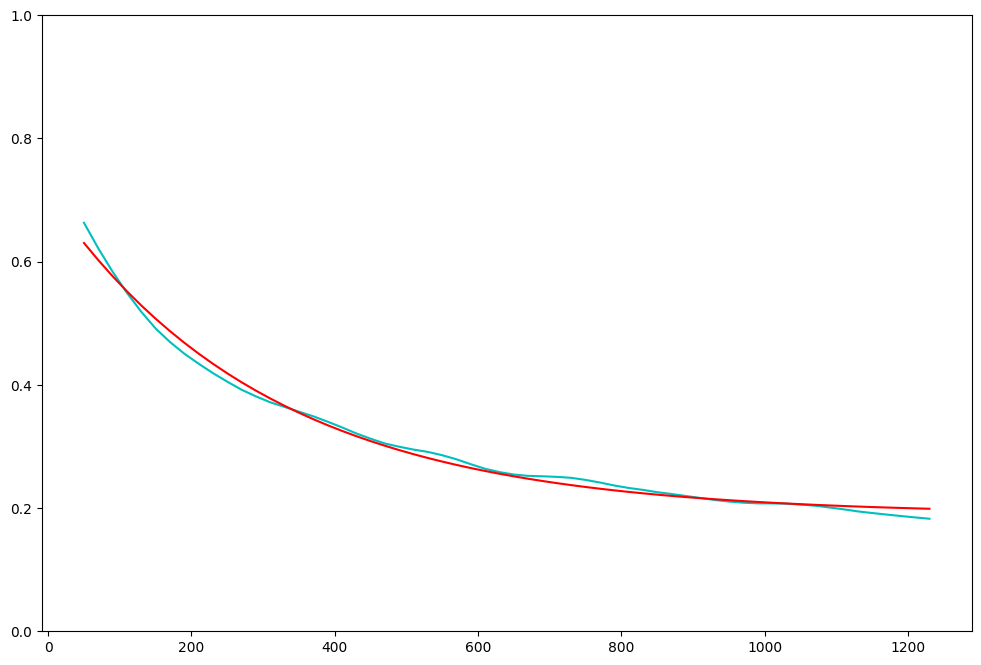

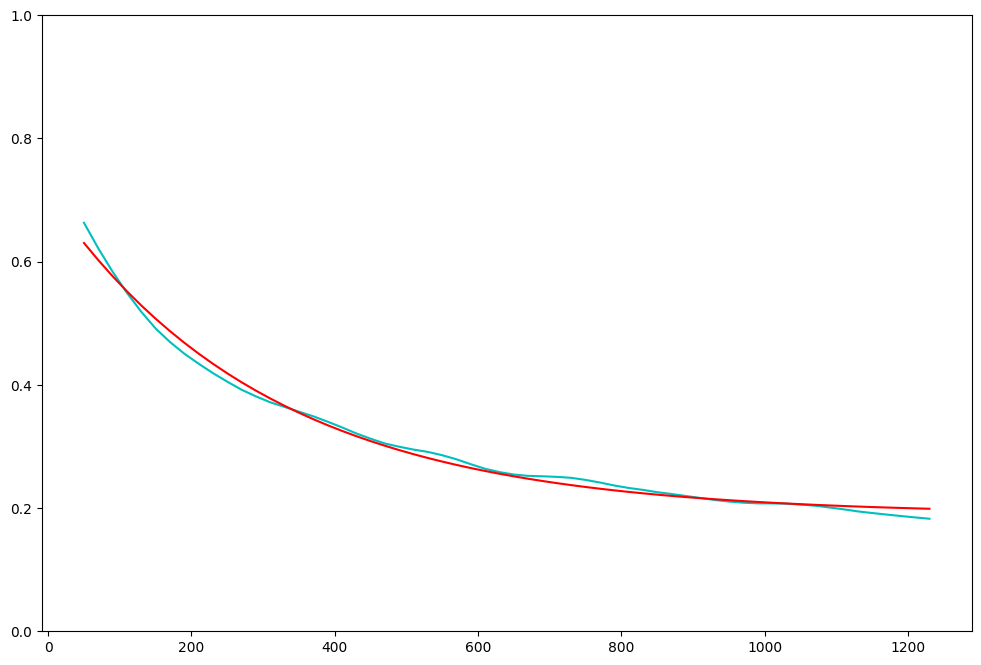

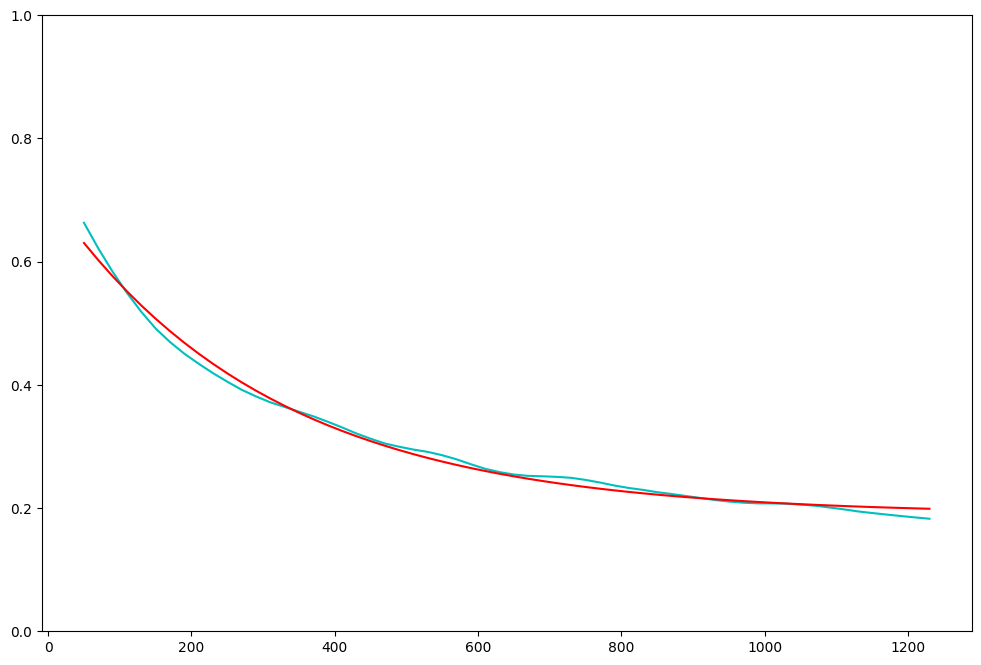

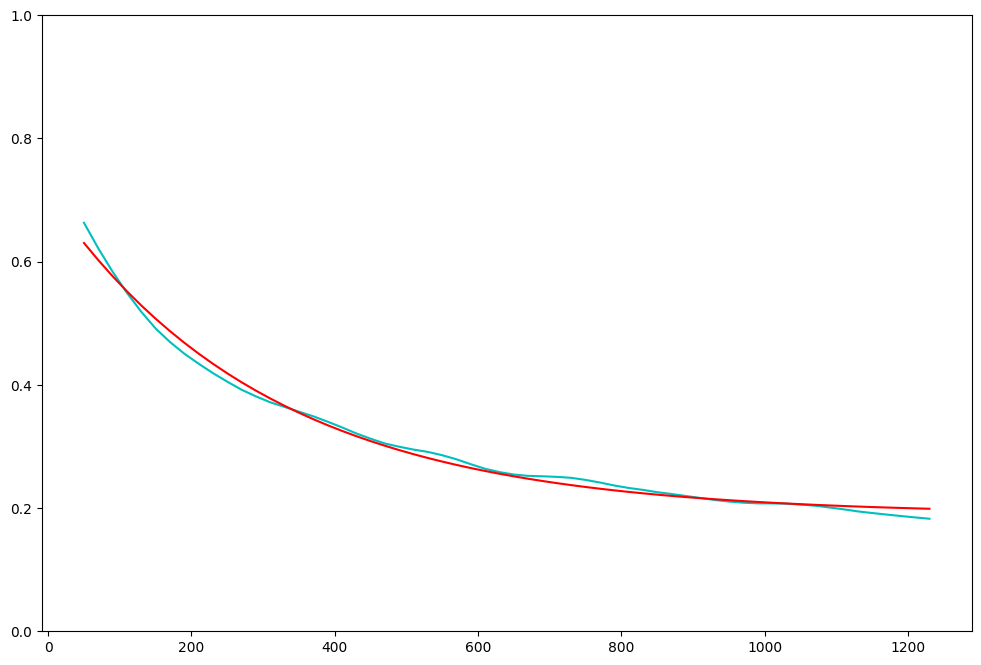

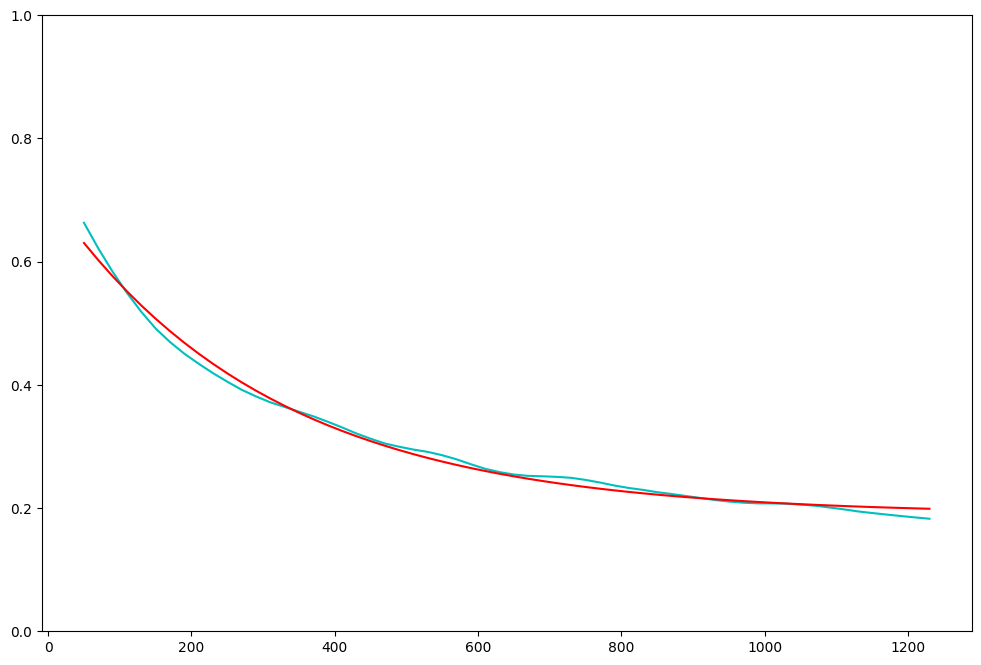

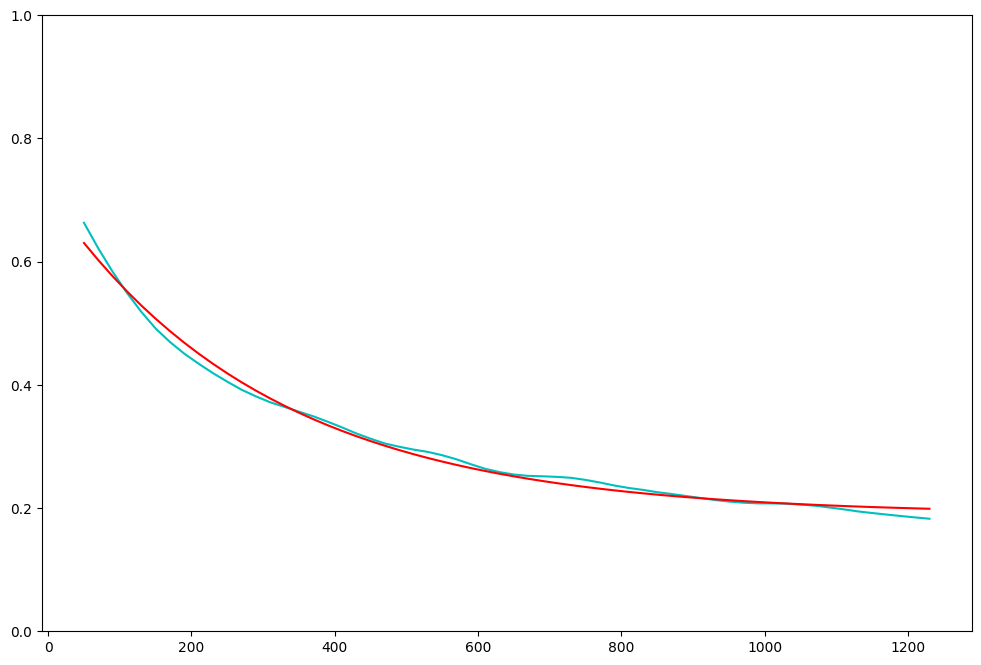

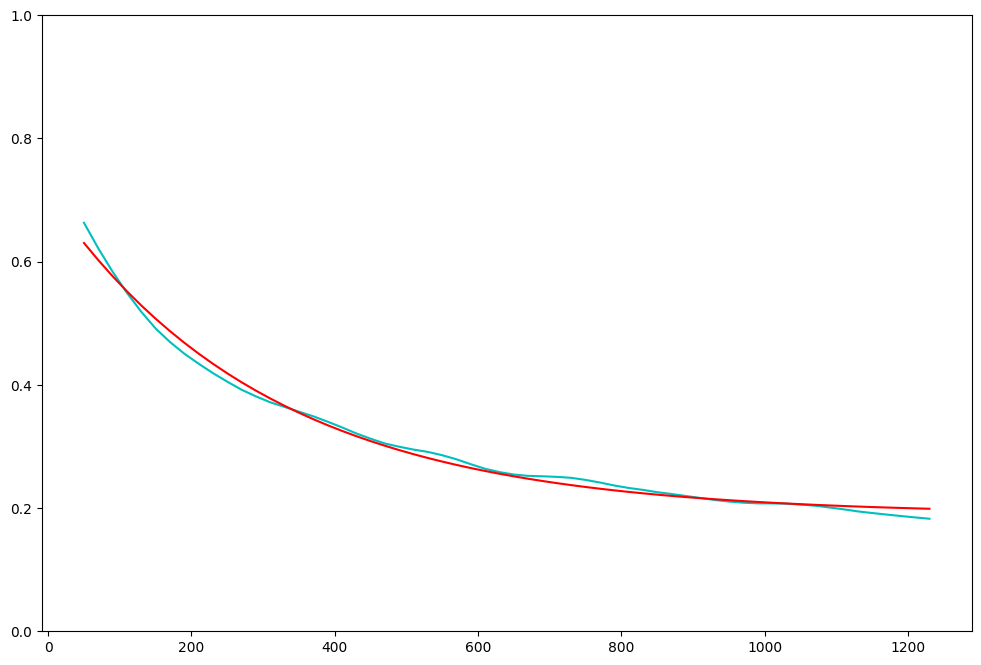

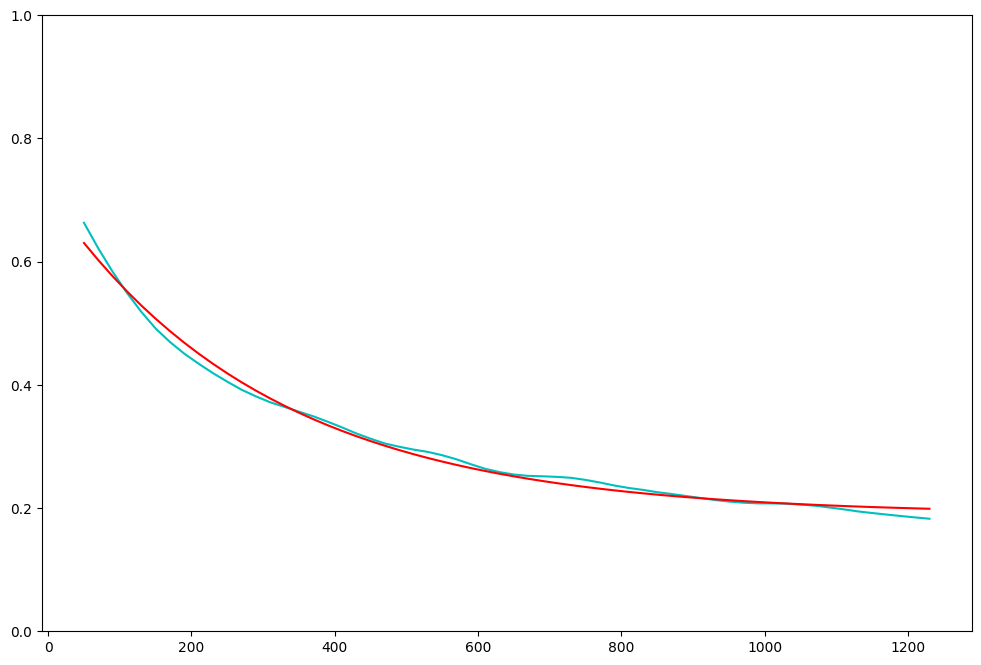

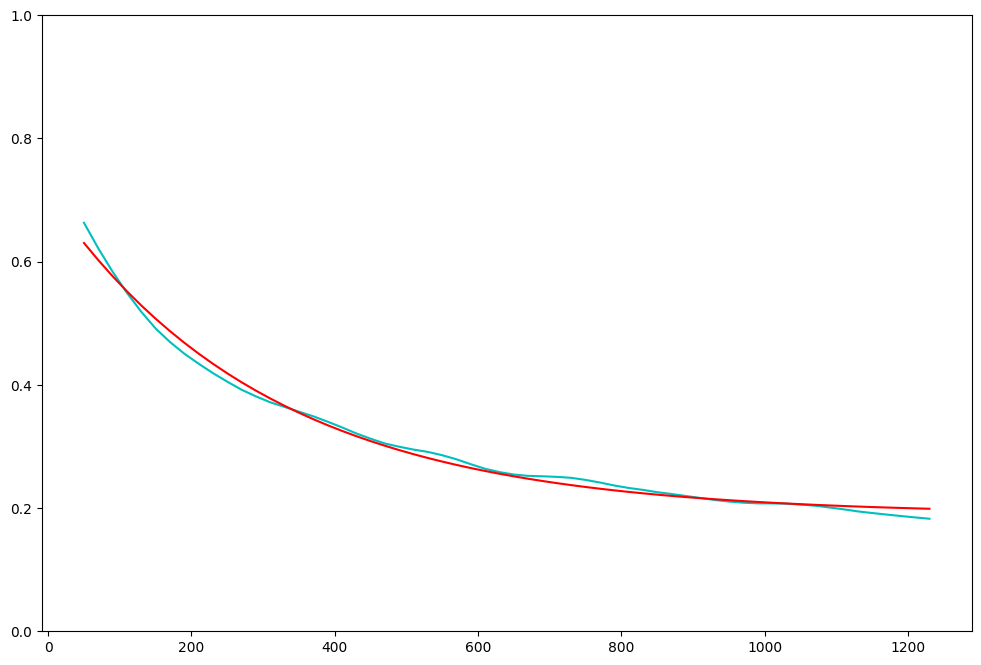

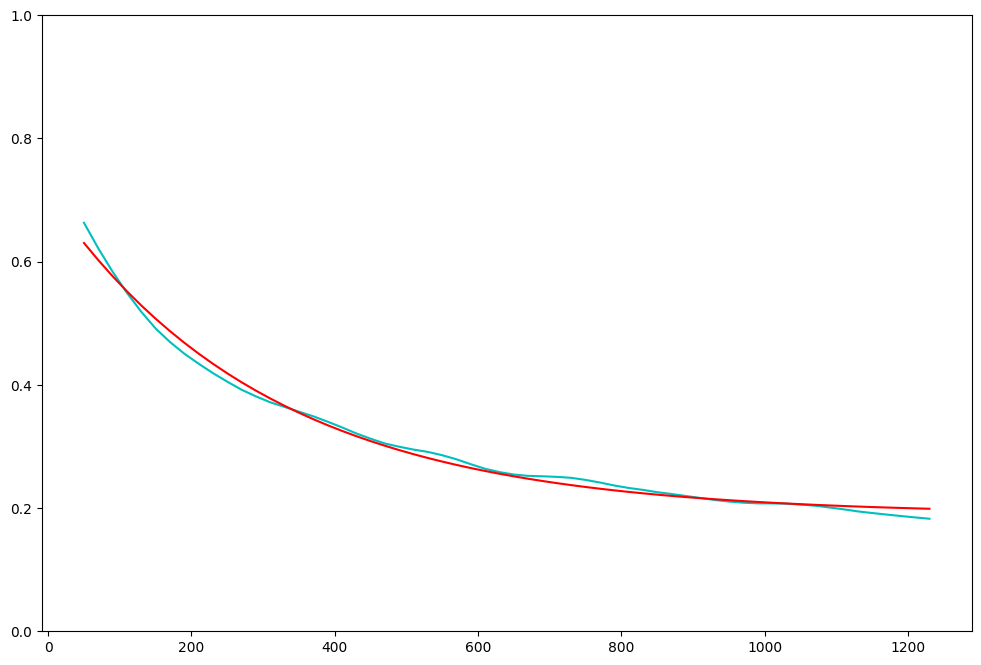

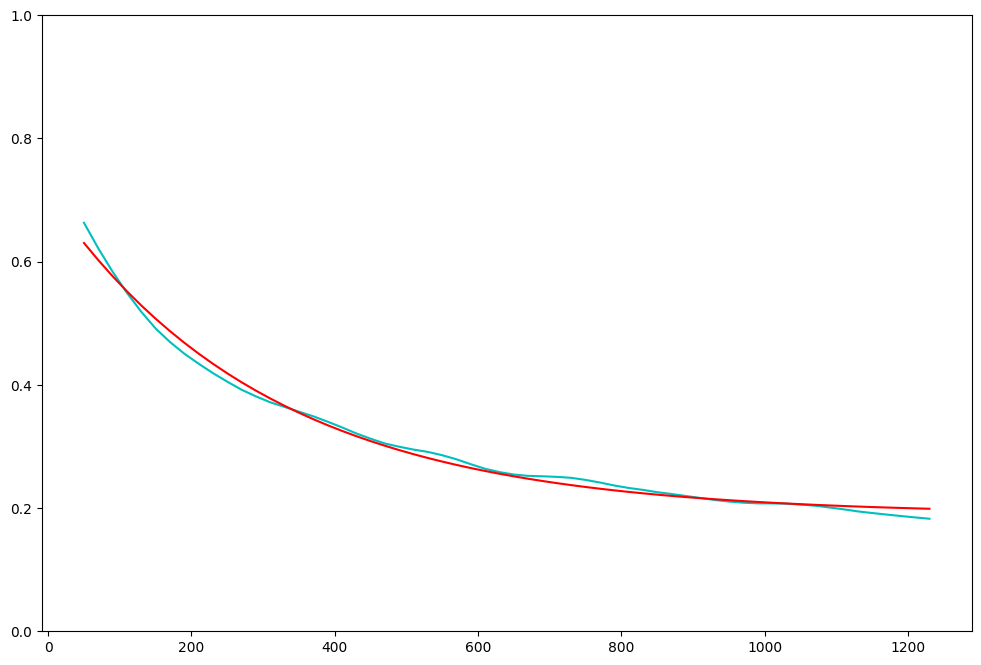

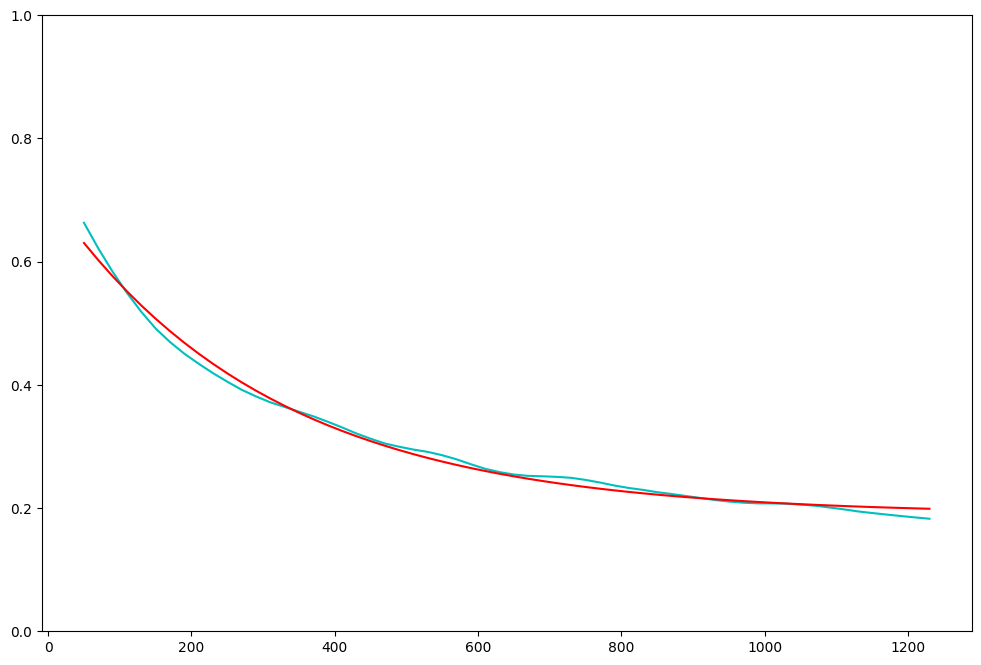

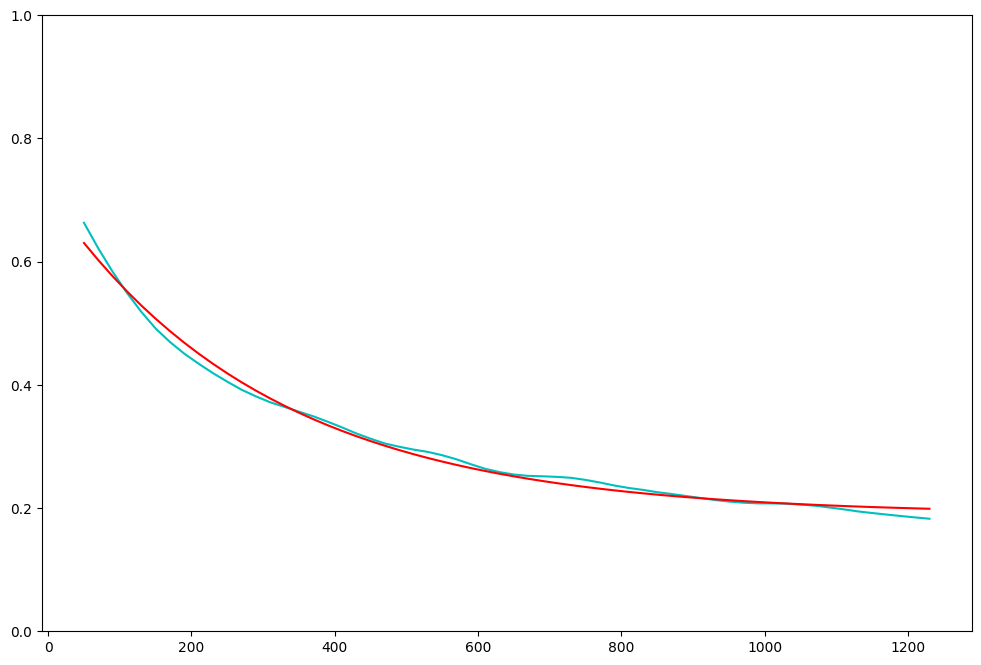

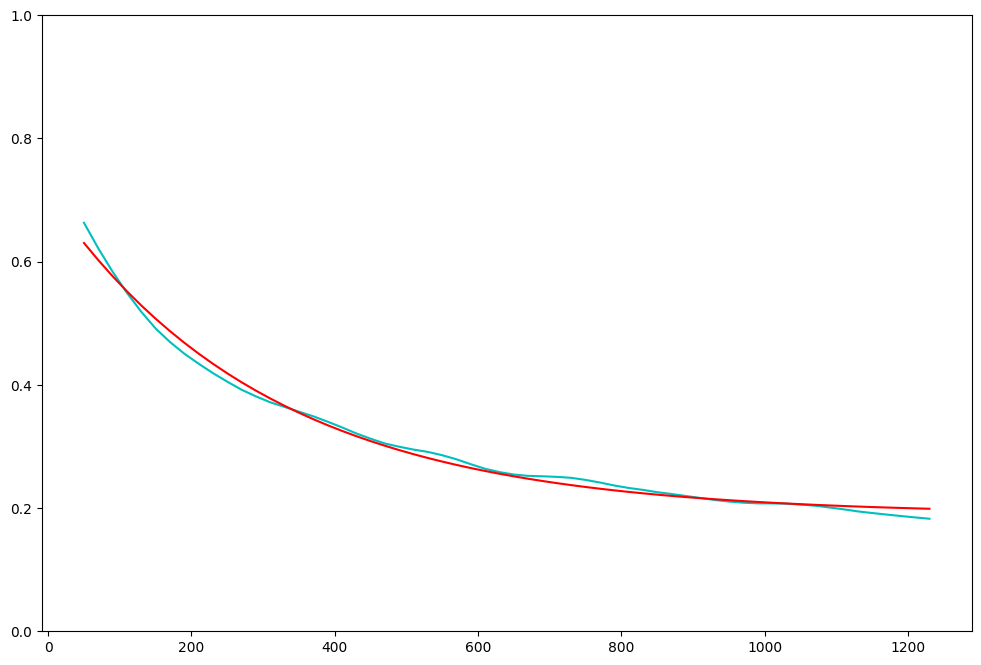

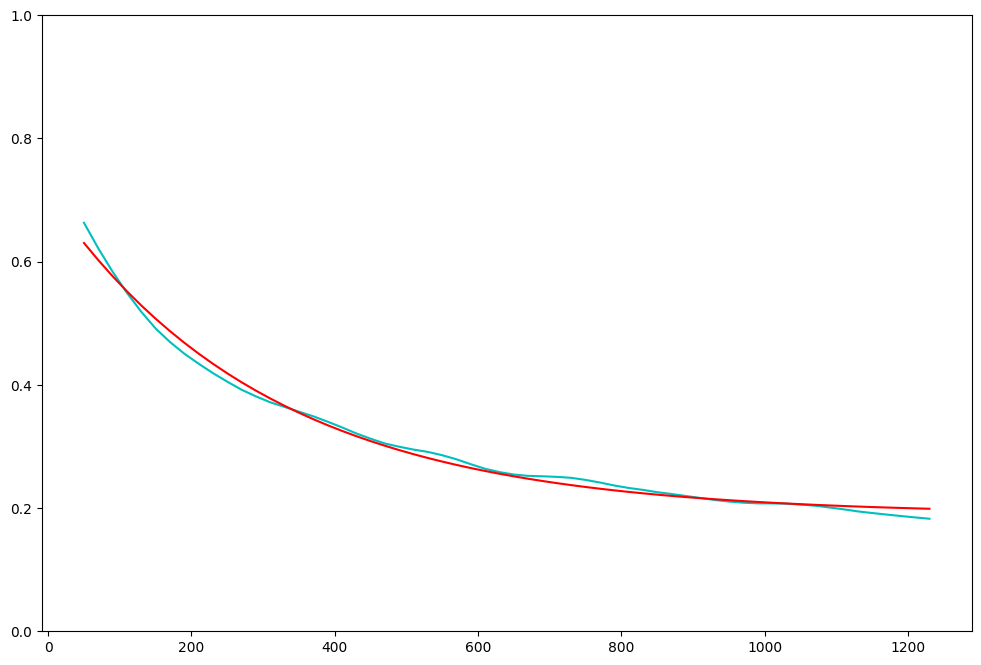

In [ ]:
slope_range = np.arange(0.00012, 0.0005, 0.00003)
hellinger_points = []
predicted_hellinger_points = []

# Calculate the saturation points for every circuit, every noise and slope level in the specified range, and store them in a list to be plotted later
for circuit_idx in range(len(names_dataset)):
    hellinger_points_circuit = []
    predicted_hellinger_points_circuit = []
    for noise_idx in range(len(noise_dataset[circuit_idx])):
        hellinger_points_noise = []
        predicted_hellinger_points_noise = []
        for slope_threshold in slope_range:
            A, B, _ = poly_hellinger_ABC[circuit_idx][noise_idx]
            point_idx = np.where(np.abs(-A * B * np.exp(-B * shots_dataset[circuit_idx])) < slope_threshold)[0]
            hellinger_points_noise.append(point_idx[0])

            A_pred, B_pred, _ = Y_reshaped[circuit_idx * len(noise_dataset[circuit_idx]) + noise_idx][0]
            point_idx_pred = np.where(np.abs(-A_pred * B_pred * np.exp(-B_pred * shots_dataset[circuit_idx])) < slope_threshold)[0]
            predicted_hellinger_points_noise.append(point_idx_pred[0])
        hellinger_points_circuit.append(hellinger_points_noise)
        predicted_hellinger_points_circuit.append(predicted_hellinger_points_noise)
    hellinger_points.append(hellinger_points_circuit)
    predicted_hellinger_points.append(predicted_hellinger_points_circuit)

poly_predicted_hellinger = np.array([
            [exponential_decay(shots_dataset[i], *Y_reshaped[i][j])
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

exponential_decay_arrays = (poly_hellinger, poly_hamming_std, poly_predicted_hellinger)
saturation_points = (hellinger_points, predicted_hellinger_points)
visualizer_pred_hellinger = TransitionPointsVisualizer(names_dataset, shots_dataset, noise_dataset, smoothed_hellinger, smoothed_hamming_std, exponential_decay=exponential_decay_arrays, saturation_points=saturation_points)
visualizer_pred_hellinger.plot_graph_dashboard(slope_idx_init=6)

### Part 4: Testing the model on unseen circuits
## Generate 10 random circuit batches, pick 3 from them and simulate them

In [22]:
# runs = 1

# # Collect circuits for multiple runs
# data = []
# for i in range(runs):
#     print(f"Run {i+1}/{runs}")
#     circuits_and_outputs = get_circuits_and_outputs()
#     data.append(circuits_and_outputs)

# print(f"Collected data for {runs} runs.")

# # Filter out non-variational circuits
# filtered_data = []
# for run_data in data:
#     names = run_data['names']
#     true_circuits = run_data['true_circuits']
#     true_dists = run_data['true_dists']
#     mirrored_circuits = run_data['mirrored_circuits']
#     true_outputs = run_data['true_outputs']

#     # Only keep circuits 1:18 from each run
#     filtered_run_data = {
#         'names': names[1:19],
#         'true_circuits': true_circuits[1:19],
#         'true_dists': true_dists[1:19],
#         'mirrored_circuits': mirrored_circuits[1:19],
#         'true_outputs': true_outputs[1:19]
#     }

#     filtered_data.append(filtered_run_data)

# # Flatten the filtered data for easier processing, edit name to include run index
# flattened_data = []
# for run_index, run_data in enumerate(filtered_data):
#     for i in range(len(run_data['names'])):
#         flattened_data.append((run_data['names'][i] + f"_r{run_index}", run_data['true_circuits'][i], run_data['true_dists'][i], run_data['mirrored_circuits'][i], run_data['true_outputs'][i], run_index))

# print(f"Filtered and flattened data for {len(flattened_data)} circuits across {runs} runs.")

# # circuit dataset is a list of tuples: (name, true_circuit, true_dist, mirrored_circuit, true_output, run_index)
# # extract using list comprehension and convert to numpy array for easier indexing
# circuit_dataset = np.array(flattened_data, dtype=object)
# names = circuit_dataset[:, 0]
# true_circuits = circuit_dataset[:, 1]
# true_dists = circuit_dataset[:, 2]
# mirrored_circuits = circuit_dataset[:, 3]
# true_outputs = circuit_dataset[:, 4]

# # simulate with 0.2% noise and varying shot counts, save results to file

# noise_levels = [0.002]
# shot_counts = np.arange(50, 1250, 20)

# for circuit_index in range(len(names)):
#     mirrored_circuit = mirrored_circuits[circuit_index]
#     true_output = true_outputs[circuit_index]

#     true_circuit = true_circuits[circuit_index]
#     true_dist = true_dists[circuit_index]

#     hellinger_data = simulate_with_noise_3D(
#              true_circuit, true_dist, noise_levels=noise_levels, shot_counts=shot_counts, distance_type='hellinger'
#     )

#     hamming_data = []
#     for i in range(10):
#         print(f"Simulation run {i+1}/10 for circuit index {circuit_index}")
#         H = simulate_with_noise_3D(
#             mirrored_circuit, true_output, noise_levels=noise_levels, shot_counts=shot_counts, distance_type='hamming'
#         )
#         hamming_data.append(H)

#     np.savez_compressed(
#         f'../data/sixth_meeting/sim_test/circuit_{circuit_index}_data.npz',
#         name=circuit_dataset[circuit_index, 0],
#         shots_array=shot_counts,
#         noise_intensities=noise_levels,
#         hamming_data=hamming_data,
#         hellinger_data=hellinger_data
#     )

# # numpy array of tuples: (name, true_circuit, true_dist, mirrored_circuit, true_output)
# circuits_info = np.array(list(zip(true_circuits, true_dists, mirrored_circuits, true_outputs)), dtype=object)

# # Load all circuit simulation data and put it into one file

# shots_dataset = []
# noise_dataset = []
# hamming_dataset = []
# hellinger_dataset = []

# for circuit_index in range(len(names)):
#     loaded = np.load(f'../data/sixth_meeting/sim_test/circuit_{circuit_index}_data.npz', allow_pickle=True)
#     shots_dataset.append(loaded['shots_array'])
#     noise_dataset.append(loaded['noise_intensities'])
#     hamming_dataset.append(loaded['hamming_data'])
#     hellinger_dataset.append(loaded['hellinger_data'])

# shots_dataset = np.array(shots_dataset, dtype=int)
# noise_dataset = np.array(noise_dataset, dtype=int)
# hamming_dataset = np.array(hamming_dataset, dtype=float)
# hellinger_dataset = np.array(hellinger_dataset, dtype=float)

# # print(names.shape, circuits_info.shape, shots_dataset.shape, noise_dataset.shape, hamming_dataset.shape, hellinger_dataset.shape)

# # Save all data into one file
# np.savez_compressed(
#     f'../data/sixth_meeting/test_circuits_simulation_dataset.npz',
#     name=names,
#     circuit_info=circuits_info,
#     shots_range=shots_dataset,
#     noise_range=noise_dataset,
#     hamming_outputs=hamming_dataset,
#     hellinger_outputs=hellinger_dataset
# )

# loaded = np.load(f'../data/sixth_meeting/test_circuits_simulation_dataset.npz', allow_pickle=True)
# names_dataset = loaded['name']
# circuits_info_dataset = loaded['circuit_info']
# shots_dataset = loaded['shots_range']
# noise_dataset = loaded['noise_range']
# hamming_dataset = loaded['hamming_outputs']
# hellinger_dataset = loaded['hellinger_outputs']

# smoothed_hellinger = np.array([
#             [savgol_filter(savgol_filter(hellinger_dataset[i][j], 11, 2), 11, 2)
#              for j in range(len(noise_dataset[i]))]
#             for i in range(len(names_dataset))
#         ])

# poly_hellinger_ABC = np.array([
#                 [fit_curve_to_data(shots_dataset[i], smoothed_hellinger[i][j])
#                 for j in range(len(noise_dataset[i]))]
#                 for i in range(len(names_dataset))
#             ])

# # get the first 2 entries of the smoothed_hellinger for every circuit and noise level, which correspond to the first 2 points of the curve, which are the most important for the prediction of the saturation point, and store them in a list to be plotted later
# hellinger_first_shots = [smoothed_hellinger[i][0][:2] for i in range(len(names_dataset))]
# hellinger_first_shots = np.array(hellinger_first_shots)

# # get supermarq features for all mirrored circuits and store them in a list, take circuits_info_dataset[i][2]
# mirrored_circuits = circuits_info_dataset[:, 2]
# supermarq_features = get_supermarq_features(mirrored_circuits)

# # For each circuit concatenate the supermarq features, the first 2 points of the smoothed hamming std curve as X, and the parameters A, B, C of the fitted hyperbolic curve to the smoothed hamming std as Y, and save it to a file
# X = []
# Y = []
# for i in range(len(names_dataset)):
#     features = supermarq_features[i]
#     hellinger_points = hellinger_first_shots[i]
#     A, B, C = poly_hellinger_ABC[i][0] # use the parameters of the first noise level for simplicity
#     X.append(np.concatenate((features, hellinger_points)))
#     Y.append([A, B, C])
# X = np.array(X)
# Y = np.array(Y)

# # Save the dataset to a file
# np.savez_compressed(
#     f'../data/sixth_meeting/test_ml_hellinger_dataset.npz',
#     X=X,
#     Y=Y
# )


## Load Simulation Hamming + Simulation Hellinger + Predict

In [ ]:
loaded = np.load(f'../data/sixth_meeting/test_circuits_simulation_dataset.npz', allow_pickle=True)
names_dataset = loaded['name']
circuits_info_dataset = loaded['circuit_info']
shots_dataset = loaded['shots_range']
noise_dataset = loaded['noise_range']
hamming_dataset = loaded['hamming_outputs']
hellinger_dataset = loaded['hellinger_outputs']


smoothed_hellinger = np.array([
            [savgol_filter(savgol_filter(hellinger_dataset[i][j], 11, 2), 11, 2)
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

smoothed_hamming = np.array([
            [[savgol_filter(savgol_filter(hamming_dataset[i][j][k], 11, 2), 11, 2)
              for k in range(len(noise_dataset[i]))]
             for j in range(10)]
            for i in range(len(names_dataset))
        ])

smoothed_hamming_std = [np.std(hamming_data, axis=0) for hamming_data in smoothed_hamming]

poly_hellinger_ABC = np.array([
                [fit_curve_to_data(shots_dataset[i], smoothed_hellinger[i][j])
                for j in range(len(noise_dataset[i]))]
                for i in range(len(names_dataset))
            ])

poly_hamming_std_ABC = np.array([
                [fit_curve_to_data(shots_dataset[i], smoothed_hamming_std[i][j])
                for j in range(len(noise_dataset[i]))]
                for i in range(len(names_dataset))
            ])

poly_hellinger = np.array([
            [exponential_decay(shots_dataset[i], *poly_hellinger_ABC[i][j])
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

poly_hamming_std = np.array([
            [exponential_decay(shots_dataset[i], *poly_hamming_std_ABC[i][j])
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

# load the training data
loaded_data = np.load('../data/sixth_meeting/test_ml_hellinger_dataset.npz')
X_raw, Y_raw = loaded_data['X'], loaded_data['Y']

scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_raw)

# Convert to PyTorch Tensors
X_tensor = torch.tensor(X_raw, dtype=torch.float32)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32)

# Create DataLoader
dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

#--- Predict Hamming A, B, C parameters
model.eval()
with torch.no_grad():
    Y_pred_scaled = model(X_tensor)
    Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.numpy())

print(Y_pred.shape)

Y_reshaped = Y_pred.reshape(18, 1, 3)

(18, 3)


ValueError: cannot reshape array of size 54 into shape (90,1,3)

## Visualize the predictions on unseen circuits

In [ ]:
slope_range = np.arange(0.00012, 0.0005, 0.00003)
hellinger_points = []
predicted_hellinger_points = []

# Calculate the saturation points for every circuit, every noise and slope level in the specified range, and store them in a list to be plotted later
for circuit_idx in range(len(names_dataset)):
    hellinger_points_circuit = []
    predicted_hellinger_points_circuit = []
    for noise_idx in range(len(noise_dataset[circuit_idx])):
        hellinger_points_noise = []
        predicted_hellinger_points_noise = []
        for slope_threshold in slope_range:
            A, B, _ = poly_hellinger_ABC[circuit_idx][noise_idx]
            point_idx = np.where(np.abs(-A * B * np.exp(-B * shots_dataset[circuit_idx])) < slope_threshold)[0]
            hellinger_points_noise.append(point_idx[0])

            A_pred, B_pred, _ = Y_reshaped[circuit_idx * len(noise_dataset[circuit_idx]) + noise_idx][0]
            point_idx_pred = np.where(np.abs(-A_pred * B_pred * np.exp(-B_pred * shots_dataset[circuit_idx])) < slope_threshold)[0]
            predicted_hellinger_points_noise.append(point_idx_pred[0])
        hellinger_points_circuit.append(hellinger_points_noise)
        predicted_hellinger_points_circuit.append(predicted_hellinger_points_noise)
    hellinger_points.append(hellinger_points_circuit)
    predicted_hellinger_points.append(predicted_hellinger_points_circuit)

poly_predicted_hellinger = np.array([
            [exponential_decay(shots_dataset[i], *Y_reshaped[i][j])
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

exponential_decay_arrays = (poly_hellinger, poly_hamming_std, poly_predicted_hellinger)
saturation_points = (hellinger_points, predicted_hellinger_points)
visualizer_pred_hellinger = TransitionPointsVisualizer(names_dataset, shots_dataset, noise_dataset, smoothed_hellinger, smoothed_hamming_std, exponential_decay=exponential_decay_arrays, saturation_points=saturation_points)
visualizer_pred_hellinger.plot_graph_dashboard(slope_idx_init=6)